<a href="https://colab.research.google.com/github/sadeesacs/FYP/blob/main/Growth_ML_V2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os
import zipfile
import shutil
import random
import math
import json
from pathlib import Path
from datetime import datetime
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import tensorflow as tf
from tensorflow.keras import layers, models

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices("GPU"))

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

TensorFlow version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
BASE_DIR = Path("/content/drive/MyDrive/Plantify_ML ")
ZIP_PATH = BASE_DIR / "Month1.zip"

EXTRACT_DIR = Path("/content/Month1_Extracted")
DATA_DIR = EXTRACT_DIR / "Data2"

if EXTRACT_DIR.exists():
    shutil.rmtree(EXTRACT_DIR)

EXTRACT_DIR.mkdir(parents=True, exist_ok=True)

with zipfile.ZipFile(ZIP_PATH, "r") as zip_ref:
    zip_ref.extractall(EXTRACT_DIR)

print("ZIP exists:", ZIP_PATH.exists())
print("Extracted to:", EXTRACT_DIR)
print("Expected data directory:", DATA_DIR)
print("Data directory exists:", DATA_DIR.exists())

ZIP exists: True
Extracted to: /content/Month1_Extracted
Expected data directory: /content/Month1_Extracted/Data2
Data directory exists: True


In [6]:
date_records = []

for folder in DATA_DIR.iterdir():
    if folder.is_dir():
        try:
            date_obj = datetime.strptime(folder.name, "%Y-%m-%d").date()
            image_paths = list(folder.glob("*.png"))

            date_records.append({
                "date": date_obj,
                "folder": folder,
                "image_count": len(image_paths)
            })
        except ValueError:
            pass

date_df = pd.DataFrame(date_records).sort_values("date").reset_index(drop=True)

display(date_df)

print("Number of date folders:", len(date_df))
print("Total images:", date_df["image_count"].sum())
print("First date:", date_df["date"].min())
print("Last date:", date_df["date"].max())

,date,folder,image_count
0,2024-05-21,/content/Month1_Extracted/Data2/2024-05-21,372
1,2024-05-22,/content/Month1_Extracted/Data2/2024-05-22,481
2,2024-05-25,/content/Month1_Extracted/Data2/2024-05-25,493
3,2024-05-26,/content/Month1_Extracted/Data2/2024-05-26,2587
4,2024-05-28,/content/Month1_Extracted/Data2/2024-05-28,1360
5,2024-05-29,/content/Month1_Extracted/Data2/2024-05-29,1394
6,2024-05-30,/content/Month1_Extracted/Data2/2024-05-30,965
7,2024-05-31,/content/Month1_Extracted/Data2/2024-05-31,1597
8,2024-06-01,/content/Month1_Extracted/Data2/2024-06-01,1983
9,2024-06-02,/content/Month1_Extracted/Data2/2024-06-02,1017


Number of date folders: 16
Total images: 26483
First date: 2024-05-21
Last date: 2024-06-10


In [7]:
first_date = date_df["date"].min()

date_df["day_number"] = date_df["date"].apply(lambda d: (d - first_date).days + 1)

max_day = date_df["day_number"].max()

early_end = math.ceil(max_day / 3)
middle_end = math.ceil((max_day * 2) / 3)

def assign_growth_stage(day):
    if day <= early_end:
        return "early_growth"
    elif day <= middle_end:
        return "middle_growth"
    else:
        return "late_growth"

date_df["label"] = date_df["day_number"].apply(assign_growth_stage)

display(date_df[["date", "day_number", "image_count", "label"]])

print("Image count by class:")
display(date_df.groupby("label")["image_count"].sum())

,date,day_number,image_count,label
0,2024-05-21,1,372,early_growth
1,2024-05-22,2,481,early_growth
2,2024-05-25,5,493,early_growth
3,2024-05-26,6,2587,early_growth
4,2024-05-28,8,1360,middle_growth
5,2024-05-29,9,1394,middle_growth
6,2024-05-30,10,965,middle_growth
7,2024-05-31,11,1597,middle_growth
8,2024-06-01,12,1983,middle_growth
9,2024-06-02,13,1017,middle_growth


Image count by class:


,image_count
label,
early_growth,3933
late_growth,9851
middle_growth,12699


In [8]:
labels = ["early_growth", "middle_growth", "late_growth"]

split_records = []

for label in labels:
    label_dates = date_df[date_df["label"] == label]["date"].tolist()

    random.seed(SEED)
    random.shuffle(label_dates)

    n = len(label_dates)

    n_train = max(1, int(n * 0.70))
    n_val = max(1, int(n * 0.15))

    train_dates = label_dates[:n_train]
    val_dates = label_dates[n_train:n_train + n_val]
    test_dates = label_dates[n_train + n_val:]

    if len(test_dates) == 0 and len(val_dates) > 1:
        test_dates.append(val_dates.pop())

    for date_value in train_dates:
        split_records.append({"date": date_value, "label": label, "split": "train"})

    for date_value in val_dates:
        split_records.append({"date": date_value, "label": label, "split": "val"})

    for date_value in test_dates:
        split_records.append({"date": date_value, "label": label, "split": "test"})

split_df = pd.DataFrame(split_records)

split_df = split_df.merge(
    date_df[["date", "folder", "image_count", "day_number"]],
    on="date",
    how="left"
)

split_df = split_df.sort_values(["split", "label", "date"]).reset_index(drop=True)

display(split_df)

print("Split image counts:")
display(split_df.groupby(["split", "label"])["image_count"].sum())

,date,label,split,folder,image_count,day_number
0,2024-05-21,early_growth,test,/content/Month1_Extracted/Data2/2024-05-21,372,1
1,2024-06-04,late_growth,test,/content/Month1_Extracted/Data2/2024-06-04,1374,15
2,2024-05-28,middle_growth,test,/content/Month1_Extracted/Data2/2024-05-28,1360,8
3,2024-06-02,middle_growth,test,/content/Month1_Extracted/Data2/2024-06-02,1017,13
4,2024-05-22,early_growth,train,/content/Month1_Extracted/Data2/2024-05-22,481,2
5,2024-05-25,early_growth,train,/content/Month1_Extracted/Data2/2024-05-25,493,5
6,2024-06-05,late_growth,train,/content/Month1_Extracted/Data2/2024-06-05,3202,16
7,2024-06-07,late_growth,train,/content/Month1_Extracted/Data2/2024-06-07,3641,18
8,2024-06-08,late_growth,train,/content/Month1_Extracted/Data2/2024-06-08,741,19
9,2024-05-29,middle_growth,train,/content/Month1_Extracted/Data2/2024-05-29,1394,9


Split image counts:


split  label        
test   early_growth      372
       late_growth      1374
       middle_growth    2377
train  early_growth      974
       late_growth      7584
       middle_growth    5939
val    early_growth     2587
       late_growth       893
       middle_growth    4383
Name: image_count, dtype: int64

In [9]:
image_records = []

for _, row in split_df.iterrows():
    folder = Path(row["folder"])
    split = row["split"]
    label = row["label"]
    date_value = row["date"]

    for img_path in folder.glob("*.png"):
        image_records.append({
            "source_path": img_path,
            "date": date_value,
            "split": split,
            "label": label
        })

images_df = pd.DataFrame(image_records)

print("Total image records:", len(images_df))

display(images_df.groupby(["split", "label"]).size())

Total image records: 26483


split  label        
test   early_growth      372
       late_growth      1374
       middle_growth    2377
train  early_growth      974
       late_growth      7584
       middle_growth    5939
val    early_growth     2587
       late_growth       893
       middle_growth    4383
dtype: int64

In [10]:
BALANCED_DIR = Path("/content/plantify_growth_dataset_v2")

if BALANCED_DIR.exists():
    shutil.rmtree(BALANCED_DIR)

for split in ["train", "val", "test"]:
    for label in labels:
        (BALANCED_DIR / split / label).mkdir(parents=True, exist_ok=True)

balanced_records = []

for split in ["train", "val", "test"]:
    split_data = images_df[images_df["split"] == split]

    class_counts = split_data.groupby("label").size()
    min_count = class_counts.min()

    if split == "train":
        target_count = min(min_count, 2000)
    elif split == "val":
        target_count = min(min_count, 500)
    else:
        target_count = min(min_count, 500)

    print(f"{split} target per class:", target_count)

    for label in labels:
        class_data = split_data[split_data["label"] == label]

        sampled_data = class_data.sample(
            n=target_count,
            random_state=SEED
        )

        balanced_records.append(sampled_data)

balanced_df = pd.concat(balanced_records).reset_index(drop=True)

display(balanced_df.groupby(["split", "label"]).size())

train target per class: 974
val target per class: 500
test target per class: 372


split  label        
test   early_growth     372
       late_growth      372
       middle_growth    372
train  early_growth     974
       late_growth      974
       middle_growth    974
val    early_growth     500
       late_growth      500
       middle_growth    500
dtype: int64

In [11]:
try:
    import cv2
    print("OpenCV imported successfully:", cv2.__version__)
except ImportError:
    !pip install -q opencv-python-headless
    import cv2
    print("OpenCV installed and imported:", cv2.__version__)

OpenCV imported successfully: 4.13.0


In [13]:
def crop_and_center_plant(input_path, output_path, image_size=224, padding_ratio=0.18):
    img_bgr = cv2.imread(str(input_path), cv2.IMREAD_COLOR)

    if img_bgr is None:
        return False

    # Detect non-black pixels because dataset background is mostly black
    mask = np.any(img_bgr > 15, axis=2)

    coords = np.column_stack(np.where(mask))

    if coords.size == 0:
        return False

    y_min, x_min = coords.min(axis=0)
    y_max, x_max = coords.max(axis=0)

    plant_h = y_max - y_min + 1
    plant_w = x_max - x_min + 1

    # Ignore extremely tiny invalid masks
    if plant_h < 10 or plant_w < 10:
        return False

    pad = int(max(plant_h, plant_w) * padding_ratio)

    y_min = max(y_min - pad, 0)
    x_min = max(x_min - pad, 0)
    y_max = min(y_max + pad, img_bgr.shape[0] - 1)
    x_max = min(x_max + pad, img_bgr.shape[1] - 1)

    crop = img_bgr[y_min:y_max + 1, x_min:x_max + 1]

    crop_h, crop_w = crop.shape[:2]
    square_size = max(crop_h, crop_w)

    square = np.zeros((square_size, square_size, 3), dtype=np.uint8)

    y_offset = (square_size - crop_h) // 2
    x_offset = (square_size - crop_w) // 2

    square[y_offset:y_offset + crop_h, x_offset:x_offset + crop_w] = crop

    resized = cv2.resize(
        square,
        (image_size, image_size),
        interpolation=cv2.INTER_AREA
    )

    output_path.parent.mkdir(parents=True, exist_ok=True)

    success = cv2.imwrite(str(output_path), resized)

    return success

In [14]:
processed_records = []
failed_records = []

for index, row in balanced_df.iterrows():
    source_path = Path(row["source_path"])
    split = row["split"]
    label = row["label"]
    date_value = row["date"]

    output_name = f"{date_value}_{source_path.stem}_v2.png"
    output_path = BALANCED_DIR / split / label / output_name

    success = crop_and_center_plant(source_path, output_path)

    if success:
        processed_records.append({
            "source_path": str(source_path),
            "output_path": str(output_path),
            "split": split,
            "label": label,
            "date": date_value
        })
    else:
        failed_records.append({
            "source_path": str(source_path),
            "split": split,
            "label": label,
            "date": date_value
        })

processed_df = pd.DataFrame(processed_records)
failed_df = pd.DataFrame(failed_records)

print("Processed images:", len(processed_df))
print("Failed images:", len(failed_df))

print("\nFinal V2 dataset counts:")
display(processed_df.groupby(["split", "label"]).size())

if len(failed_df) > 0:
    print("Failed examples:")
    display(failed_df.head())

Processed images: 5529
Failed images: 9

Final V2 dataset counts:


split  label        
test   early_growth     372
       late_growth      369
       middle_growth    372
train  early_growth     974
       late_growth      973
       middle_growth    970
val    early_growth     500
       late_growth      500
       middle_growth    499
dtype: int64

Failed examples:


,source_path,split,label,date
0,/content/Month1_Extracted/Data2/2024-05-31/cam...,train,middle_growth,2024-05-31
1,/content/Month1_Extracted/Data2/2024-05-30/cam...,train,middle_growth,2024-05-30
2,/content/Month1_Extracted/Data2/2024-05-29/cam...,train,middle_growth,2024-05-29
3,/content/Month1_Extracted/Data2/2024-05-31/cam...,train,middle_growth,2024-05-31
4,/content/Month1_Extracted/Data2/2024-06-07/cam...,train,late_growth,2024-06-07


In [15]:
processed_csv_path = BASE_DIR / "model_v2_processed_images.csv"
split_csv_path = BASE_DIR / "model_v2_date_splits.csv"

processed_df.to_csv(processed_csv_path, index=False)
split_df.to_csv(split_csv_path, index=False)

print("Saved:", processed_csv_path)
print("Saved:", split_csv_path)

Saved: /content/drive/MyDrive/Plantify_ML /model_v2_processed_images.csv
Saved: /content/drive/MyDrive/Plantify_ML /model_v2_date_splits.csv


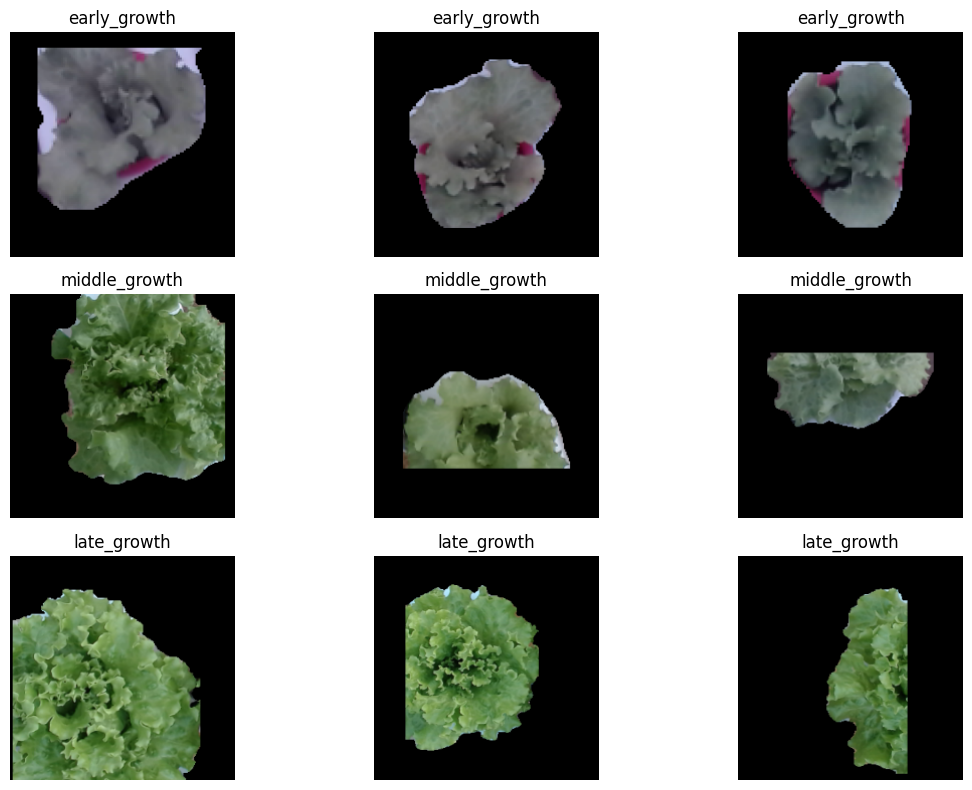

In [16]:
plt.figure(figsize=(12, 8))

plot_index = 1

for label in labels:
    image_paths = list((BALANCED_DIR / "train" / label).glob("*.png"))
    sample_paths = random.sample(image_paths, min(3, len(image_paths)))

    for img_path in sample_paths:
        img = Image.open(img_path).convert("RGB")

        plt.subplot(3, 3, plot_index)
        plt.imshow(img)
        plt.title(label)
        plt.axis("off")

        plot_index += 1

plt.tight_layout()
plt.show()

In [17]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    BALANCED_DIR / "train",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int",
    shuffle=True,
    seed=SEED
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    BALANCED_DIR / "val",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int",
    shuffle=False
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    BALANCED_DIR / "test",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int",
    shuffle=False
)

class_names = train_ds.class_names
num_classes = len(class_names)

print("Class names:", class_names)
print("Number of classes:", num_classes)

Found 2917 files belonging to 3 classes.
Found 1499 files belonging to 3 classes.
Found 1113 files belonging to 3 classes.
Class names: ['early_growth', 'late_growth', 'middle_growth']
Number of classes: 3


In [18]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.prefetch(buffer_size=AUTOTUNE)

In [19]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.04),
    layers.RandomZoom(0.08),
    layers.RandomContrast(0.10),
], name="data_augmentation_v2")

In [20]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False

preprocess_input = tf.keras.applications.mobilenet_v2.preprocess_input

inputs = layers.Input(shape=(224, 224, 3))

x = data_augmentation(inputs)
x = preprocess_input(x)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)

x = layers.Dense(
    128,
    activation="relu",
    kernel_regularizer=tf.keras.regularizers.l2(0.0001)
)(x)

x = layers.Dropout(0.4)(x)

outputs = layers.Dense(num_classes, activation="softmax")(x)

model_v2 = models.Model(inputs, outputs)

model_v2.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model_v2.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation_v2            │ (None, 224, 224, 3)    │             0 │
│ (Sequential)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,339 (9.24 MB)

 Trainable params: 164,355 (642.01 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [21]:
V2_CHECKPOINT_PATH = BASE_DIR / "best_plantify_growth_model_v2.keras"

callbacks_v2 = [
    tf.keras.callbacks.ModelCheckpoint(
        filepath=str(V2_CHECKPOINT_PATH),
        monitor="val_accuracy",
        save_best_only=True,
        mode="max",
        verbose=1
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=5,
        mode="max",
        restore_best_weights=True,
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=2,
        min_lr=1e-7,
        verbose=1
    )
]

In [22]:
EPOCHS_STAGE_1 = 15

history_v2_stage1 = model_v2.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_STAGE_1,
    callbacks=callbacks_v2
)

Epoch 1/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.5525 - loss: 0.9488
Epoch 1: val_accuracy improved from None to 0.51167, saving model to /content/drive/MyDrive/Plantify_ML /best_plantify_growth_model_v2.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Plantify_ML /best_plantify_growth_model_v2.keras
92/92 ━━━━━━━━━━━━━━━━━━━━ 22s 123ms/step - accuracy: 0.6781 - loss: 0.7334 - val_accuracy: 0.5117 - val_loss: 1.1154 - learning_rate: 1.0000e-04
Epoch 2/15
91/92 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.7866 - loss: 0.4915
Epoch 2: val_accuracy improved from 0.51167 to 0.54303, saving model to /content/drive/MyDrive/Plantify_ML /best_plantify_growth_model_v2.keras

Epoch 2: finished saving model to /content/drive/MyDrive/Plantify_ML /best_plantify_growth_model_v2.keras
92/92 ━━━━━━━━━━━━━━━━━━━━ 8s 88ms/step - accuracy: 0.8005 - loss: 0.4800 - val_accuracy: 0.5430 - val_loss: 1.1769 - learning_rate: 1.0000e-04
Epoch 3/15
91/92 ━━━━━━━━━━━━━━━━━━━━ 0s 

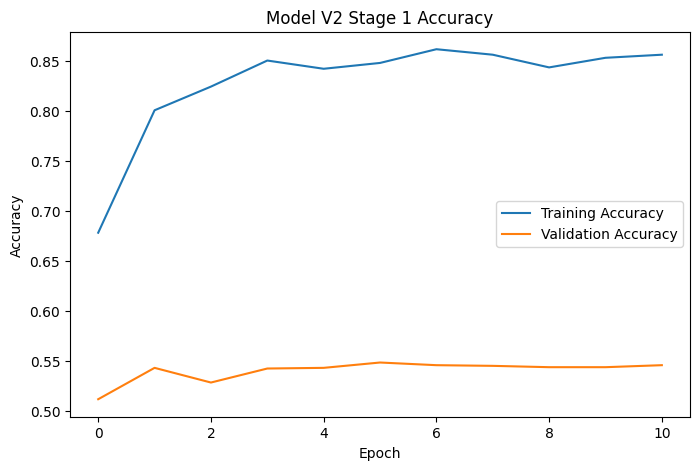

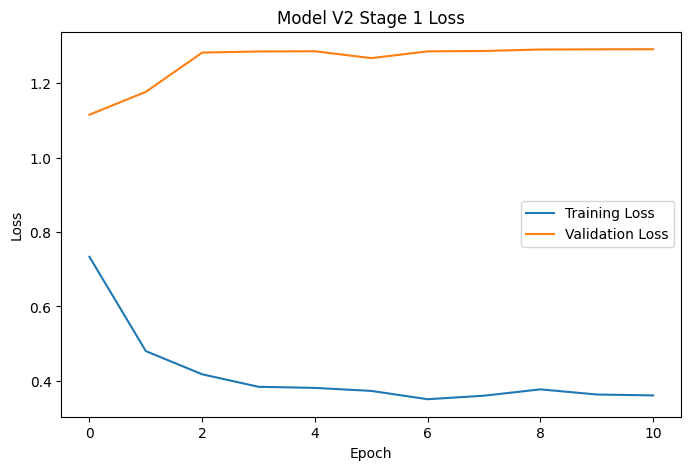

In [23]:
def plot_training_history(history, title_prefix):
    plt.figure(figsize=(8, 5))
    plt.plot(history.history["accuracy"], label="Training Accuracy")
    plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
    plt.title(f"{title_prefix} Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(history.history["loss"], label="Training Loss")
    plt.plot(history.history["val_loss"], label="Validation Loss")
    plt.title(f"{title_prefix} Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.show()

plot_training_history(history_v2_stage1, "Model V2 Stage 1")

In [25]:
base_model.trainable = True

# Freeze most layers, fine-tune only the last 35 layers
for layer in base_model.layers[:-35]:
    layer.trainable = False

# Keep BatchNormalization layers frozen
for layer in base_model.layers:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False

model_v2.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.00001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model_v2.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation_v2            │ (None, 224, 224, 3)    │             0 │
│ (Sequential)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,339 (9.24 MB)

 Trainable params: 1,772,419 (6.76 MB)

 Non-trainable params: 649,920 (2.48 MB)

In [26]:
EPOCHS_STAGE_2 = 10

history_v2_stage2 = model_v2.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_STAGE_2,
    callbacks=callbacks_v2
)

Epoch 1/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - accuracy: 0.8525 - loss: 0.3644
Epoch 1: val_accuracy did not improve from 0.54837
92/92 ━━━━━━━━━━━━━━━━━━━━ 19s 122ms/step - accuracy: 0.8478 - loss: 0.3616 - val_accuracy: 0.5317 - val_loss: 1.4168 - learning_rate: 1.0000e-05
Epoch 2/10
91/92 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - accuracy: 0.8712 - loss: 0.3233
Epoch 2: val_accuracy did not improve from 0.54837

Epoch 2: ReduceLROnPlateau reducing learning rate to 2.9999999242136253e-06.
92/92 ━━━━━━━━━━━━━━━━━━━━ 10s 108ms/step - accuracy: 0.8704 - loss: 0.3140 - val_accuracy: 0.5410 - val_loss: 1.4829 - learning_rate: 1.0000e-05
Epoch 3/10
91/92 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - accuracy: 0.8829 - loss: 0.3027
Epoch 3: val_accuracy did not improve from 0.54837
92/92 ━━━━━━━━━━━━━━━━━━━━ 10s 107ms/step - accuracy: 0.8872 - loss: 0.2889 - val_accuracy: 0.5430 - val_loss: 1.5171 - learning_rate: 3.0000e-06
Epoch 4/10
91/92 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - accuracy: 0.9008 - loss

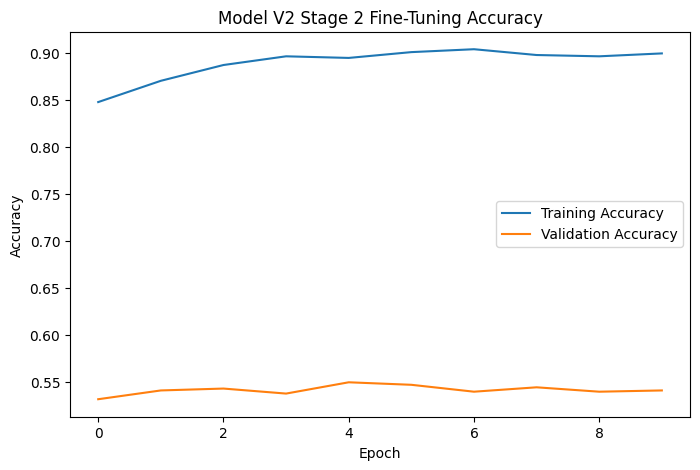

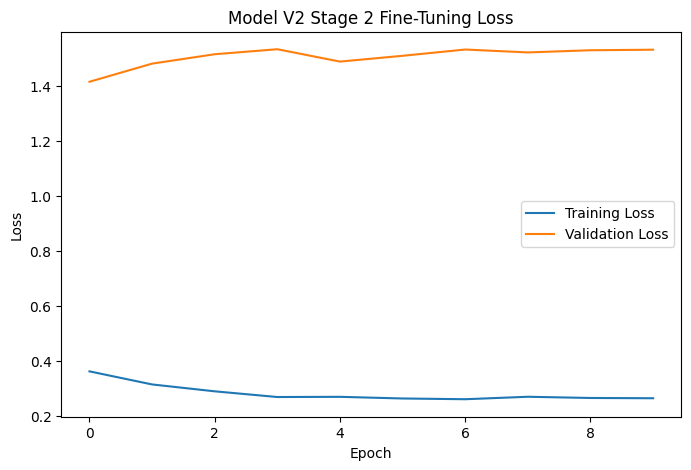

In [27]:
plot_training_history(history_v2_stage2, "Model V2 Stage 2 Fine-Tuning")

In [28]:
best_model_v2 = tf.keras.models.load_model(str(V2_CHECKPOINT_PATH))

print("Loaded best V2 model from:", V2_CHECKPOINT_PATH)

Loaded best V2 model from: /content/drive/MyDrive/Plantify_ML /best_plantify_growth_model_v2.keras


In [29]:
test_loss, test_accuracy = best_model_v2.evaluate(test_ds)

print("Model V2 Test Loss:", test_loss)
print("Model V2 Test Accuracy:", test_accuracy)

35/35 ━━━━━━━━━━━━━━━━━━━━ 5s 64ms/step - accuracy: 0.6155 - loss: 0.9274
Model V2 Test Loss: 0.9273502826690674
Model V2 Test Accuracy: 0.6154537200927734


               precision    recall  f1-score   support

 early_growth       0.72      0.51      0.60       372
  late_growth       0.59      0.67      0.63       369
middle_growth       0.58      0.66      0.62       372

     accuracy                           0.62      1113
    macro avg       0.63      0.62      0.61      1113
 weighted avg       0.63      0.62      0.61      1113



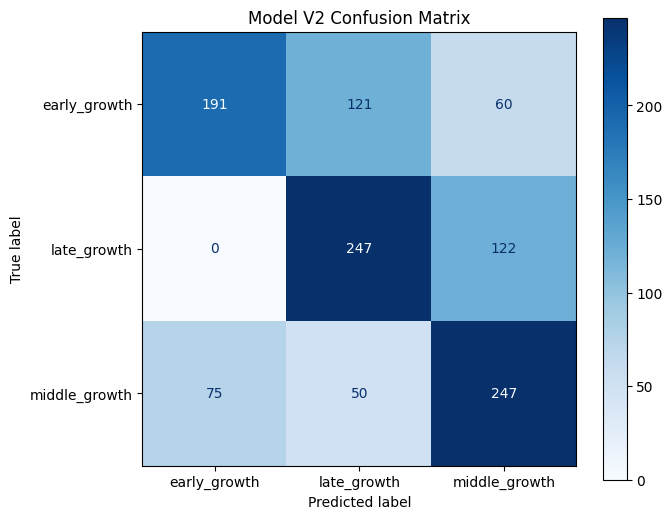

In [30]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

y_true = []
y_pred = []

for images, labels_batch in test_ds:
    predictions = best_model_v2.predict(images, verbose=0)
    predicted_labels = np.argmax(predictions, axis=1)

    y_true.extend(labels_batch.numpy())
    y_pred.extend(predicted_labels)

print(classification_report(y_true, y_pred, target_names=class_names))

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

fig, ax = plt.subplots(figsize=(7, 6))
disp.plot(ax=ax, cmap="Blues", values_format="d")
plt.title("Model V2 Confusion Matrix")
plt.show()

In [31]:
FINAL_MODEL_V2_PATH = BASE_DIR / "plantify_mobilenetv2_growth_model_v2.keras"
LABELS_V2_PATH = BASE_DIR / "class_names_v2.json"

best_model_v2.save(str(FINAL_MODEL_V2_PATH))

with open(LABELS_V2_PATH, "w") as f:
    json.dump(class_names, f)

print("Saved final V2 model:", FINAL_MODEL_V2_PATH)
print("Saved V2 labels:", LABELS_V2_PATH)

Saved final V2 model: /content/drive/MyDrive/Plantify_ML /plantify_mobilenetv2_growth_model_v2.keras
Saved V2 labels: /content/drive/MyDrive/Plantify_ML /class_names_v2.json


In [32]:
history_stage1_df = pd.DataFrame(history_v2_stage1.history)
history_stage1_df["stage"] = "frozen_base"

history_stage2_df = pd.DataFrame(history_v2_stage2.history)
history_stage2_df["stage"] = "fine_tuning"

history_v2_df = pd.concat(
    [history_stage1_df, history_stage2_df],
    ignore_index=True
)

HISTORY_V2_PATH = BASE_DIR / "model_v2_training_history.csv"

history_v2_df.to_csv(HISTORY_V2_PATH, index=False)

print("Saved V2 training history:", HISTORY_V2_PATH)

Saved V2 training history: /content/drive/MyDrive/Plantify_ML /model_v2_training_history.csv


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


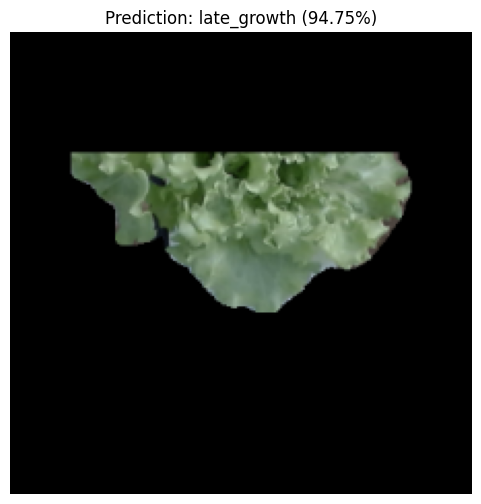

Image path: /content/plantify_growth_dataset_v2/test/late_growth/2024-06-04_cam2=17-01-35_segment_2_v2.png
Predicted class: late_growth
Confidence: 94.74771022796631

All predictions:
early_growth : 0.01 %
late_growth : 94.75 %
middle_growth : 5.24 %


In [33]:
test_image_paths = list((BALANCED_DIR / "test").rglob("*.png"))
sample_path = random.choice(test_image_paths)

img = Image.open(sample_path).convert("RGB")
img_resized = img.resize(IMG_SIZE)

img_array = tf.keras.utils.img_to_array(img_resized)
img_array = np.expand_dims(img_array, axis=0)

predictions = best_model_v2.predict(img_array)[0]

predicted_index = np.argmax(predictions)
predicted_class = class_names[predicted_index]
confidence = float(predictions[predicted_index]) * 100

plt.figure(figsize=(6, 6))
plt.imshow(img)
plt.axis("off")
plt.title(f"Prediction: {predicted_class} ({confidence:.2f}%)")
plt.show()

print("Image path:", sample_path)
print("Predicted class:", predicted_class)
print("Confidence:", confidence)

print("\nAll predictions:")
for class_name, score in zip(class_names, predictions):
    print(class_name, ":", round(float(score) * 100, 2), "%")

In [34]:
misclassified_records = []

all_test_paths = []
all_test_labels = []

for class_index, class_name in enumerate(class_names):
    class_paths = list((BALANCED_DIR / "test" / class_name).glob("*.png"))
    all_test_paths.extend(class_paths)
    all_test_labels.extend([class_index] * len(class_paths))

for img_path, true_label_index in zip(all_test_paths, all_test_labels):
    img = Image.open(img_path).convert("RGB").resize(IMG_SIZE)

    img_array = tf.keras.utils.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)

    preds = best_model_v2.predict(img_array, verbose=0)[0]
    pred_index = int(np.argmax(preds))

    if pred_index != true_label_index:
        misclassified_records.append({
            "path": img_path,
            "true_label": class_names[true_label_index],
            "predicted_label": class_names[pred_index],
            "confidence": float(preds[pred_index])
        })

misclassified_df = pd.DataFrame(misclassified_records)

print("Total misclassified images:", len(misclassified_df))
display(misclassified_df.head())

Total misclassified images: 428


,path,true_label,predicted_label,confidence
0,/content/plantify_growth_dataset_v2/test/early...,early_growth,middle_growth,0.581984
1,/content/plantify_growth_dataset_v2/test/early...,early_growth,late_growth,0.449903
2,/content/plantify_growth_dataset_v2/test/early...,early_growth,middle_growth,0.366676
3,/content/plantify_growth_dataset_v2/test/early...,early_growth,late_growth,0.436462
4,/content/plantify_growth_dataset_v2/test/early...,early_growth,middle_growth,0.589054
